# Max Chelminski

## HW5 API

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from olclient.openlibrary import OpenLibrary
import re
import time

I ran out of daily queries for the BLS, so I had to register for an API key and figure out how to use requests with the key.

## 1. **Use the BLS Data Finder 1.1 available here to import a BLS variable/field (using the BLS web API) of your choosing.**

In [2]:
bls_key = 'bc755fe836e84230accf2fb22f11fe46'
base_url = 'https://api.bls.gov/publicAPI/v2/timeseries/data/'
series = {
    'id': 'IPUEN3341__M020000000',
    'name': 'Annual combined inputs costs (millions of current dollars) for NAICS 3341, computer and peripheral equipment manufacturing, U.S. total'
}
payload = {
    'seriesid': [series['id']],
    'registrationkey': bls_key
}

In [3]:
r = requests.post('https://api.bls.gov/publicAPI/v2/timeseries/data/', 
                  data=json.dumps(payload), 
                  headers={'Content-type': 'application/json'}).json()

In [4]:
print(f"Status: {r['status']}")

Status: REQUEST_SUCCEEDED


In [5]:
print(r.keys())

dict_keys(['status', 'responseTime', 'message', 'Results'])


In [6]:
results = r['Results']['series'][0]['data']
print(results[0])

{'year': '2022', 'period': 'A01', 'periodName': 'Annual', 'latest': 'true', 'value': '18371.786', 'footnotes': [{}]}


In [7]:
dates = ['{} {}'.format(i['periodName'], i['year']) for i in results]
dates_cleaned = [d.replace('Annual', 'December') for d in dates]
index = pd.to_datetime(dates_cleaned)
data = {series['id']: [float(i['value']) for i in results]}

df = pd.DataFrame(index=index, data=data).iloc[::-1]
df.head()

C:\Users\Max\AppData\Local\Temp\ipykernel_28832\2225466546.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  index = pd.to_datetime(dates_cleaned)


,IPUEN3341__M020000000
2020-12-01,15846.943
2021-12-01,17039.887
2022-12-01,18371.786


## 2. **Using the BLS web API, create your own custom function which can interact with the BLS web API. Your function should take three input parameters: name base_url_in, series_in, and title_in and return the relevant data series as a pd.DataFrame object. Test your function by replicating the GET request you sent above for #1.**

In [8]:
def api_data_importer(base_url_in, id_in, name_in, key_in):
    tmp_series = {'id': id_in, 'name': name_in}

    payload = {
    'seriesid': [tmp_series['id']],
    'registrationkey': key_in
    }
    
    tmp_r = requests.post('https://api.bls.gov/publicAPI/v2/timeseries/data/', 
                  data=json.dumps(payload), 
                  headers={'Content-type': 'application/json'}).json()
    
    print('Status: ' + tmp_r['status'])

    tmp_results = tmp_r['Results']['series'][0]['data']

    tmp_dates = ['{} {}'.format(i['periodName'], i['year']) for i in tmp_results]
    tmp_dates_cleaned = [d.replace('Annual', 'December') for d in tmp_dates]
    tmp_index = pd.to_datetime(tmp_dates_cleaned)
    tmp_data = {tmp_series['id']: pd.to_numeric([i['value'] for i in tmp_results], errors='coerce')}

    tmp_df = pd.DataFrame(index=tmp_index, data=tmp_data).iloc[::-1]
    print(name_in)
    return tmp_df

In [9]:
test_df = api_data_importer(base_url, 'IPUEN3341__M020000000', 'Annual combined inputs costs (millions of current dollars) for NAICS 3341, computer and peripheral equipment manufacturing, U.S. total', bls_key)
test_df.head()

Status: REQUEST_SUCCEEDED
Annual combined inputs costs (millions of current dollars) for NAICS 3341, computer and peripheral equipment manufacturing, U.S. total


C:\Users\Max\AppData\Local\Temp\ipykernel_28832\782885398.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tmp_index = pd.to_datetime(tmp_dates_cleaned)


,IPUEN3341__M020000000
2020-12-01,15846.943
2021-12-01,17039.887
2022-12-01,18371.786


## 3. **Go to these three links: link1, link2, link3. On these webpages, you will see three different time series data sets. For each, you will also see both a Series Title and ID. Using the function you wrote to fetch data from the BLS web API, import these data sets into Python as three separate pd.Data.Frame objects.**

In [11]:
# Link 1
df1 = api_data_importer(base_url, 'APU0000709112', 'Milk, fresh, whole, fortified, per gal. (3.8 lit) in U.S. city average, average price, not seasonally adjusted', bls_key)
df1.head()

Status: REQUEST_SUCCEEDED
Milk, fresh, whole, fortified, per gal. (3.8 lit) in U.S. city average, average price, not seasonally adjusted


C:\Users\Max\AppData\Local\Temp\ipykernel_28832\782885398.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tmp_index = pd.to_datetime(tmp_dates_cleaned)


,APU0000709112
2024-01-01,3.958
2024-02-01,3.940
2024-03-01,3.893
2024-04-01,3.868
2024-05-01,3.864


In [13]:
# Link 2
df2 = api_data_importer(base_url, 'APU000074714', 'Gasoline, unleaded regular, per gallon/3.785 liters in U.S. city average, average price, not seasonally adjusted', bls_key)
df2.head()

Status: REQUEST_SUCCEEDED
Gasoline, unleaded regular, per gallon/3.785 liters in U.S. city average, average price, not seasonally adjusted


C:\Users\Max\AppData\Local\Temp\ipykernel_28832\782885398.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tmp_index = pd.to_datetime(tmp_dates_cleaned)


,APU000074714
2024-01-01,3.221
2024-02-01,3.359
2024-03-01,3.581
2024-04-01,3.776
2024-05-01,3.755


In [14]:
# Link 3
df3 = api_data_importer(base_url, 'APU0000708111', 'Eggs, grade A, large, per doz. in U.S. city average, average price, not seasonally adjusted', bls_key)
df3.head()

Status: REQUEST_SUCCEEDED
Eggs, grade A, large, per doz. in U.S. city average, average price, not seasonally adjusted


C:\Users\Max\AppData\Local\Temp\ipykernel_28832\782885398.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tmp_index = pd.to_datetime(tmp_dates_cleaned)


,APU0000708111
2024-01-01,2.522
2024-02-01,2.996
2024-03-01,2.992
2024-04-01,2.864
2024-05-01,2.699


## 4. **Merge the data sets together into a single pd.DataFrame and make a time series plot showing how the CPI for these three goods has changed over the last 24 months. Each good should be shown as a unique line with different coloring/patterns and a matching legend (I suggest using the matplotlib library to do this).**

In [15]:
merged_df1 = pd.merge(df1, df2, left_index=True, right_index=True)
merged_df = pd.merge(merged_df1, df3, left_index=True, right_index=True)

merged_df.head()

,APU0000709112,APU000074714,APU0000708111
2024-01-01,3.958,3.221,2.522
2024-02-01,3.940,3.359,2.996
2024-03-01,3.893,3.581,2.992
2024-04-01,3.868,3.776,2.864
2024-05-01,3.864,3.755,2.699


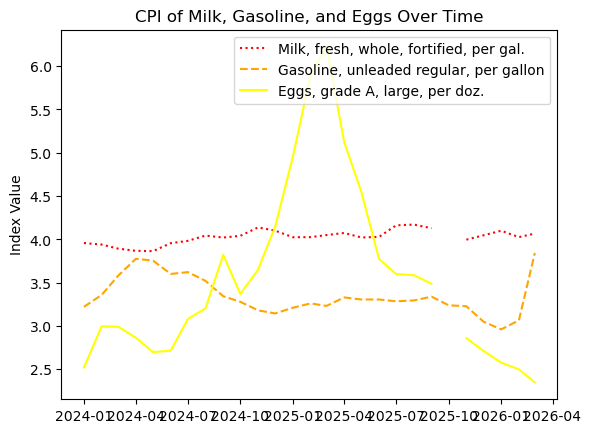

In [16]:
plt.figure()
plt.plot(merged_df.index, merged_df.iloc[:,0], color='red', ls = 'dotted', label='Milk, fresh, whole, fortified, per gal.')
plt.plot(merged_df.index, merged_df.iloc[:,1], color='orange', ls = 'dashed', label='Gasoline, unleaded regular, per gallon')
plt.plot(merged_df.index, merged_df.iloc[:,2], color='yellow', label='Eggs, grade A, large, per doz.')
plt.title('CPI of Milk, Gasoline, and Eggs Over Time')
plt.xlabel(None)
plt.ylabel('Index Value')
plt.legend()
plt.show()

## 5. **In the lecture notes, refer to the section entitled "No Python Package? Manipulate URL directly". Can you update the code in the New York Times article search API URL so that you return article data for Hillary Clinton for the time range April 1, 2024 - April 4, 2024? How many TOTAL articles were returned by this API search?**

In [17]:
api_key = 'cZU9enRUd8pjDd9H1g4nDACL63weaI16Wq9HkuxJ9p1FjmKL'
term = 'Hillary+Clinton'
begin_date = '20240401'
end_date = '20240404'

final_url = 'http://api.nytimes.com/svc/search/v2/articlesearch.json?q=' + term + '&begin_date=' + begin_date + '&end_date=' + end_date + '&api-key=' + api_key
print(final_url)

http://api.nytimes.com/svc/search/v2/articlesearch.json?q=Hillary+Clinton&begin_date=20240401&end_date=20240404&api-key=cZU9enRUd8pjDd9H1g4nDACL63weaI16Wq9HkuxJ9p1FjmKL


In [18]:
#r = requests.get(final_url).json()
#print(r.keys())

### For whatever reason, the above code doesn't seem to work (NYT changed api rules maybe?), however the link returns a dictionary which seems to be what we need

In [19]:
r = {"status":"OK","copyright":"Copyright (c) 2026 The New York Times Company. All Rights Reserved.","response":{"docs":[{"abstract":"Inside the notorious “catch and kill” campaign that now stands at the heart of the former president’s legal trial.","byline":{"original":"By Lachlan Cartwright"},"document_type":"article","headline":{"main":"What I Saw Working at The National Enquirer During Donald Trump’s Rise","kicker":"","print_headline":"EX-NATIONAL ENQUIRER EDITOR TELLS ALL! Catch and Kill! Photoshopped Hill! Italian Spies!"},"_id":"nyt://article/3211e3f0-4388-5f19-884b-051e5821435f","keywords":[{"name":"Organization","value":"National Enquirer","rank":1},{"name":"Organization","value":"American Media Inc","rank":2},{"name":"Person","value":"Trump, Donald J","rank":3},{"name":"Person","value":"Pecker, David J","rank":4},{"name":"Person","value":"Howard, Dylan","rank":5},{"name":"Subject","value":"New York State Criminal Case Against Trump (71543-23)","rank":6},{"name":"Subject","value":"Media","rank":7},{"name":"Subject","value":"News Sources, Confidential Status of","rank":8},{"name":"Subject","value":"Nondisclosure Agreements","rank":9},{"name":"Subject","value":"Presidential Election of 2016","rank":10},{"name":"Subject","value":"Rumors and Misinformation","rank":11},{"name":"Subject","value":"Campaign Finance","rank":12},{"name":"Subject","value":"Adultery","rank":13},{"name":"Person","value":"Clifford, Stephanie (1979- )","rank":14},{"name":"Person","value":"McDougal, Karen (1971- )","rank":15},{"name":"Subject","value":"audio-neutral-informative","rank":16}],"multimedia":{"caption":"","credit":"Photo illustration by Pablo Delcan","default":{"url":"https://static01.nyt.com/images/2024/04/07/magazine/07Mag-Enquirer-01/07Mag-Enquirer-01-articleLarge-v2.jpg","height":653,"width":600},"thumbnail":{"url":"https://static01.nyt.com/images/2024/04/07/magazine/07Mag-Enquirer-01/07Mag-Enquirer-01-thumbStandard.jpg","height":75,"width":75}},"news_desk":"Magazine","print_page":"26","print_section":"MM","pub_date":"2024-04-03T09:04:03Z","section_name":"Magazine","snippet":"Inside the notorious “catch and kill” campaign that now stands at the heart of the former president’s legal trial.","source":"The New York Times","subsection_name":"","type_of_material":"News","uri":"nyt://article/3211e3f0-4388-5f19-884b-051e5821435f","web_url":"https://www.nytimes.com/2024/04/03/magazine/national-enquirer-trump-lachlan-cartwright.html","word_count":6394},{"abstract":"Oren Etzioni was once an optimist about artificial intelligence. Now, his nonprofit, TrueMedia.org, is offering tools for fighting A.I.-manipulated content.","byline":{"original":"By Cade Metz and Tiffany Hsu"},"document_type":"article","headline":{"main":"An A.I. Researcher Takes On Election Deepfakes","kicker":"","print_headline":"‘Terrified’ A.I. Researcher Targets Election Deepfakes"},"_id":"nyt://article/e75ea126-164f-5942-a86a-4781dfdd9cd2","keywords":[{"name":"Subject","value":"Artificial Intelligence","rank":1},{"name":"Subject","value":"Social Media","rank":2},{"name":"Subject","value":"Rumors and Misinformation","rank":3},{"name":"Subject","value":"Computers and the Internet","rank":4},{"name":"Organization","value":"Allen Institute for AI","rank":5},{"name":"Organization","value":"TrueMedia.org","rank":6},{"name":"Person","value":"Etzioni, Oren","rank":7},{"name":"Subject","value":"Presidential Election of 2024","rank":8},{"name":"Subject","value":"United States Politics and Government","rank":9}],"multimedia":{"caption":"Oren Etzioni at The AI Institute.","credit":"Kyle Johnson for The New York Times","default":{"url":"https://static01.nyt.com/images/2024/04/02/multimedia/02DEEPFAKE-DETECTION-Oren-02-hqfj/02DEEPFAKE-DETECTION-Oren-02-hqfj-articleLarge.jpg","height":480,"width":600},"thumbnail":{"url":"https://static01.nyt.com/images/2024/04/02/multimedia/02DEEPFAKE-DETECTION-Oren-02-hqfj/02DEEPFAKE-DETECTION-Oren-02-hqfj-thumbStandard.jpg","height":75,"width":75}},"news_desk":"Business","print_page":"1","print_section":"B","pub_date":"2024-04-02T16:00:12Z","section_name":"Technology","snippet":"Oren Etzioni was once an optimist about artificial intelligence. Now, his nonprofit, TrueMedia.org, is offering tools for fighting A.I.-manipulated content.","source":"The New York Times","subsection_name":"","type_of_material":"News","uri":"nyt://article/e75ea126-164f-5942-a86a-4781dfdd9cd2","web_url":"https://www.nytimes.com/2024/04/02/technology/an-ai-researcher-takes-on-election-deepfakes.html","word_count":1089},{"abstract":"Simon Rosenberg has spent the past two years telling Democrats they need to calm down. His Biden-will-win prediction is his next big test.","byline":{"original":"By Adam Nagourney"},"document_type":"article","headline":{"main":"Many Democrats Are Worried Trump Will Beat Biden. This One Isn’t.","kicker":"","print_headline":"Not All Democrats Fear Biden Will Lose to Trump"},"_id":"nyt://article/58c63816-3116-5608-b18d-878e39eb7e14","keywords":[{"name":"Person","value":"Biden, Joseph R Jr","rank":1},{"name":"Person","value":"Dukakis, Michael S","rank":2},{"name":"Person","value":"Plouffe, David","rank":3},{"name":"Person","value":"Silver, Nate","rank":4},{"name":"Subject","value":"Presidential Election of 2024","rank":5},{"name":"Subject","value":"Polls and Public Opinion","rank":6},{"name":"Person","value":"Trump, Donald J","rank":7}],"multimedia":{"caption":"Simon Rosenberg, a Democratic strategist and consultant, is pushing back against the Democratic doom and gloom.","credit":"Jason Andrew for The New York Times","default":{"url":"https://static01.nyt.com/images/2024/04/03/multimedia/03pol-rosenberg--01-fbpk/03pol-rosenberg--01-fbpk-articleLarge.jpg","height":800,"width":600},"thumbnail":{"url":"https://static01.nyt.com/images/2024/04/03/multimedia/03pol-rosenberg--01-fbpk/03pol-rosenberg--01-fbpk-thumbStandard-v2.jpg","height":75,"width":75}},"news_desk":"Politics","print_page":"18","print_section":"A","pub_date":"2024-04-03T18:26:38Z","section_name":"U.S.","snippet":"Simon Rosenberg has spent the past two years telling Democrats they need to calm down. His Biden-will-win prediction is his next big test.","source":"The New York Times","subsection_name":"Politics","type_of_material":"News","uri":"nyt://article/58c63816-3116-5608-b18d-878e39eb7e14","web_url":"https://www.nytimes.com/2024/04/03/us/politics/simon-rosenberg-trump-biden.html","word_count":1754},{"abstract":"He oversaw design of new ballparks for the Baltimore Orioles and San Diego Padres, as well as renovations for Fenway Park with the Boston Red Sox.","byline":{"original":"By Richard Sandomir"},"document_type":"article","headline":{"main":"Larry Lucchino, Top Executive at Three M.L.B. Teams, Dies at 78","kicker":"","print_headline":"Larry Lucchino, Top Executive at Three M.L.B. Teams, Dies at 78"},"_id":"nyt://article/47823689-65b3-5250-ba60-8c10cff9ed0e","keywords":[{"name":"Subject","value":"Deaths (Obituaries)","rank":1},{"name":"Subject","value":"Baseball","rank":2},{"name":"Subject","value":"Stadiums and Arenas","rank":3},{"name":"Person","value":"Lucchino, Larry","rank":4},{"name":"Organization","value":"Baltimore Orioles","rank":5},{"name":"Organization","value":"Boston Red Sox","rank":6},{"name":"Organization","value":"San Diego Padres","rank":7},{"name":"Organization","value":"Fenway Park (Boston)","rank":8},{"name":"Organization","value":"Oriole Park at Camden Yards","rank":9}],"multimedia":{"caption":"Larry Lucchino in 2008 as president of the Red Sox. Speaking of Boston’s rivalry with the Yankees, he described the New York team as “the evil empire.” The name stuck.","credit":"Issei Kato/Reuters","default":{"url":"https://static01.nyt.com/images/2024/04/04/multimedia/01Lucchino-mjzk-print4/01Lucchino-mjzk-articleLarge.jpg","height":441,"width":600},"thumbnail":{"url":"https://static01.nyt.com/images/2024/04/04/multimedia/01Lucchino-mjzk-print4/01Lucchino-mjzk-thumbStandard.jpg","height":75,"width":75}},"news_desk":"Obits","print_page":"11","print_section":"B","pub_date":"2024-04-02T16:23:20Z","section_name":"Sports","snippet":"He oversaw design of new ballparks for the Baltimore Orioles and San Diego Padres, as well as renovations for Fenway Park with the Boston Red Sox.","source":"The New York Times","subsection_name":"Baseball","type_of_material":"Obituary (Obit)","uri":"nyt://article/47823689-65b3-5250-ba60-8c10cff9ed0e","web_url":"https://www.nytimes.com/2024/04/02/sports/baseball/larry-lucchino-dead.html","word_count":1285},{"abstract":"Long before the killings of seven workers in Gaza, World Central Kitchen pioneered a new way to deliver emergency relief, using local labor and recipes.","byline":{"original":"By Kim Severson"},"document_type":"article","headline":{"main":"How José Andrés and His Corps of Cooks Became Leaders in Disaster Aid","kicker":"","print_headline":"Comfort in a Disaster Through Local Chefs  Using Local Recipes"},"_id":"nyt://article/5b4d71e7-2855-534f-b725-7cfd9c88f3e5","keywords":[{"name":"Person","value":"Andres, Jose (1969- )","rank":1},{"name":"Organization","value":"World Central Kitchen","rank":2},{"name":"Location","value":"Israel","rank":3},{"name":"Location","value":"Rafah (Gaza Strip)","rank":4},{"name":"Subject","value":"Humanitarian Aid","rank":5},{"name":"Subject","value":"Israel-Gaza War (2023- )","rank":6},{"name":"Location","value":"Gaza Strip","rank":7},{"name":"Subject","value":"audio-neutral-informative","rank":8},{"name":"Subject","value":"audio-negative-tragedy","rank":9}],"multimedia":{"caption":"José Andrés, the Spanish chef who founded World Central Kitchen, delivering food in Kherson, Ukraine, in 2022.","credit":"Efrem Lukatsky/Associated Press","default":{"url":"https://static01.nyt.com/images/2024/04/02/multimedia/02food-andres1-pwcb/02food-andres1-pwcb-articleLarge-v2.jpg","height":397,"width":600},"thumbnail":{"url":"https://static01.nyt.com/images/2024/04/02/multimedia/02food-andres1-pwcb/02food-andres1-pwcb-thumbStandard-v2.jpg","height":75,"width":75}},"news_desk":"Dining","print_page":"9","print_section":"A","pub_date":"2024-04-02T22:31:38Z","section_name":"Food","snippet":"Long before the killings of seven workers in Gaza, World Central Kitchen pioneered a new way to deliver emergency relief, using local labor and recipes.","source":"The New York Times","subsection_name":"","type_of_material":"News","uri":"nyt://article/5b4d71e7-2855-534f-b725-7cfd9c88f3e5","web_url":"https://www.nytimes.com/2024/04/02/dining/jose-andres-central-kitchen-disaster-aid.html","word_count":1456}],"metadata":{"hits":5,"offset":0,"time":165}}}

In [20]:
print(r.keys())

dict_keys(['status', 'copyright', 'response'])


In [21]:
clinton = pd.DataFrame(r['response']['docs'])
print(clinton.shape)
print(clinton.columns)
clinton

(5, 19)
Index(['abstract', 'byline', 'document_type', 'headline', '_id', 'keywords',
       'multimedia', 'news_desk', 'print_page', 'print_section', 'pub_date',
       'section_name', 'snippet', 'source', 'subsection_name',
       'type_of_material', 'uri', 'web_url', 'word_count'],
      dtype='object')


,abstract,byline,document_type,headline,_id,keywords,multimedia,news_desk,print_page,print_section,pub_date,section_name,snippet,source,subsection_name,type_of_material,uri,web_url,word_count
0,Inside the notorious “catch and kill” campaign...,{'original': 'By Lachlan Cartwright'},article,{'main': 'What I Saw Working at The National E...,nyt://article/3211e3f0-4388-5f19-884b-051e5821...,"[{'name': 'Organization', 'value': 'National E...","{'caption': '', 'credit': 'Photo illustration ...",Magazine,26,MM,2024-04-03T09:04:03Z,Magazine,Inside the notorious “catch and kill” campaign...,The New York Times,,News,nyt://article/3211e3f0-4388-5f19-884b-051e5821...,https://www.nytimes.com/2024/04/03/magazine/na...,6394
1,Oren Etzioni was once an optimist about artifi...,{'original': 'By Cade Metz and Tiffany Hsu'},article,{'main': 'An A.I. Researcher Takes On Election...,nyt://article/e75ea126-164f-5942-a86a-4781dfdd...,"[{'name': 'Subject', 'value': 'Artificial Inte...",{'caption': 'Oren Etzioni at The AI Institute....,Business,1,B,2024-04-02T16:00:12Z,Technology,Oren Etzioni was once an optimist about artifi...,The New York Times,,News,nyt://article/e75ea126-164f-5942-a86a-4781dfdd...,https://www.nytimes.com/2024/04/02/technology/...,1089
2,Simon Rosenberg has spent the past two years t...,{'original': 'By Adam Nagourney'},article,{'main': 'Many Democrats Are Worried Trump Wil...,nyt://article/58c63816-3116-5608-b18d-878e39eb...,"[{'name': 'Person', 'value': 'Biden, Joseph R ...","{'caption': 'Simon Rosenberg, a Democratic str...",Politics,18,A,2024-04-03T18:26:38Z,U.S.,Simon Rosenberg has spent the past two years t...,The New York Times,Politics,News,nyt://article/58c63816-3116-5608-b18d-878e39eb...,https://www.nytimes.com/2024/04/03/us/politics...,1754
3,He oversaw design of new ballparks for the Bal...,{'original': 'By Richard Sandomir'},article,"{'main': 'Larry Lucchino, Top Executive at Thr...",nyt://article/47823689-65b3-5250-ba60-8c10cff9...,"[{'name': 'Subject', 'value': 'Deaths (Obituar...",{'caption': 'Larry Lucchino in 2008 as preside...,Obits,11,B,2024-04-02T16:23:20Z,Sports,He oversaw design of new ballparks for the Bal...,The New York Times,Baseball,Obituary (Obit),nyt://article/47823689-65b3-5250-ba60-8c10cff9...,https://www.nytimes.com/2024/04/02/sports/base...,1285
4,Long before the killings of seven workers in G...,{'original': 'By Kim Severson'},article,{'main': 'How José Andrés and His Corps of Coo...,nyt://article/5b4d71e7-2855-534f-b725-7cfd9c88...,"[{'name': 'Person', 'value': 'Andres, Jose (19...","{'caption': 'José Andrés, the Spanish chef who...",Dining,9,A,2024-04-02T22:31:38Z,Food,Long before the killings of seven workers in G...,The New York Times,,News,nyt://article/5b4d71e7-2855-534f-b725-7cfd9c88...,https://www.nytimes.com/2024/04/02/dining/jose...,1456


We have 5 articles that mentioned Hillary Clinton between those dates.

## 6. **In this question, we will connect to the Open Library API. Open Library has a package called openlibrary-client which makes this easy. Using their Python interface documentation, your task is to figure out how to use the authors function listed on this webpage to import Christopher Moore's works. There is no API key required to use this package. Once you have successfully used openlibrary-client to pull in data for this author, write a for loop to display the following message, making sure you align the numbers as is done here:**

**Hints: 1) The Christopher Moore you need to find was born in 1957. 2) For more information, you can explore the function code here: https://github.com/internetarchive/openlibrary-client/blob/master/olclient/openlibrary.py or do help(ol.Author) in Python. 3) String alignment was covered briefly in the JuPyter notebook on strings.**

In [22]:
#!pip install git+https://github.com/internetarchive/openlibrary-client.git

In [23]:
ol = OpenLibrary()
ol.session.headers.update({'User-Agent': 'ColumbiaHW5 (maximilian.chel@gmail.com)'})

In [24]:
search_results = ol.Author.search("Christopher Moore")
print(search_results)

[{'alternate_names': ['Moore, Christopher'], 'birth_date': '1 January 1957', 'key': '/authors/OL2629911A', 'name': 'Christopher Moore', 'work_count': 77, 'works': ['Practical Demonkeeping: A Comedy of Horrors'], 'subjects': ['Fiction', 'Fiction, humorous, general', 'San francisco (calif.), fiction', 'Fiction, humorous', 'Vampires, fiction', 'Vampires', 'San Francisco (Calif.)', 'History', 'New York Times bestseller', 'Large type books']}]


In [25]:
for author in search_results:
    birth_date = author.get('birth_date', '')
    
    if '1957' in str(birth_date):
        key = author['key'].split('/')[-1]
        break

In [26]:
author = ol.Author.get(key)
results = author.works()
book_list = results.get('entries', [])

In [27]:
for work in book_list:
    title = work.get('title')
    date = work.get('first_publish_date')
    if date:
        print(f"In {date:<25} {'Moore published':^}\t    {title}")

In May 25, 2004              Moore published	    Coyote Blue
In August 1, 1999            Moore published	    Der Lustmolch
In January 9, 2007           Moore published	    Fluke CD
In February 27, 2007         Moore published	    Fluke LP
In March 27, 2007            Moore published	    Lamb CD
In November 1, 2007          Moore published	    Lamb Special Gift Ed
In 1984                      Moore published	    The Loyalists
In May 25, 2004              Moore published	    The Lust Lizard of Melancholy Cove
In October 12, 2004          Moore published	    The Stupidest Angel CD
In January 10, 2006          Moore published	    Stupidest Angel, The  LP
In November 5, 1998          Moore published	    Trench Fever
In January 16, 2007          Moore published	    You Suck CD
In 1997                      Moore published	    1867
In July 2000                 Moore published	    Island of the Sequined Love Nun
In January 31, 2005          Moore published	    The Stupidest Angel
In June 15, 2

## 7. **Do the same exercise with the Italian author Gianrico Carofiglio, a contemporary Italian crime writer. This time compare the results to a direct API query using the requests library in Python: https://openlibrary.org/search.json?author_key=INSERTKEY a) Which call returns more keys about each book? Why do you think that is? When would you choose one over the other? b) Loop over the results and print different messages based on the language of the book. If the book's language was Italian print "TITLE NAME was published in Italian". If it was published in English, print "TITLE NAME was published in English". (Make sure to include the actual title name and not TITLE NAME.)**
**Hint: Find the language key within the results to separate the loop into different conditions.**

In [28]:
search_results = ol.Author.search("Gianrico Carofiglio")

print(search_results)

[{'alternate_names': ['Carofiglio Gianrico'], 'birth_date': '1961', 'key': '/authors/OL1450328A', 'name': 'Gianrico Carofiglio', 'work_count': 43, 'works': ['The past is a foreign country'], 'subjects': ['Fiction', 'Italy, fiction', 'Fiction, legal', 'Italy', 'Legal stories', 'Lawyers, fiction', 'Italian fiction', 'Fiction, thrillers, general', 'Lawyers', 'Fiction, thrillers']}]


In [29]:
key = search_results[0]['key'].split('/')[-1]

In [30]:
author = ol.Author.get(key)
results = author.works()
book_list = results.get('entries', [])

In [31]:
for work in book_list:
    title = work.get('title')
    date = work.get('first_publish_date') or 'Unknown'
    print(f"In {date:<}\t{'Carofiglio published':^}\t{title}")

In Unknown	Carofiglio published	Con parole precise
In Unknown	Carofiglio published	La nuova manomissione delle parole
In Unknown	Carofiglio published	Con i piedi nel fango
In Unknown	Carofiglio published	עד בעל כורחו
In Unknown	Carofiglio published	Passeggeri notturni
In Unknown	Carofiglio published	Il paradosso del poliziotto
In Unknown	Carofiglio published	La disciplina di Penelope
In Unknown	Carofiglio published	Z zamkniętymi oczami
In Unknown	Carofiglio published	Zasada równowagi
In Unknown	Carofiglio published	Les yeux fermés
In Unknown	Carofiglio published	De volmaaktheid van het tijdelijke
In Unknown	Carofiglio published	Met gesloten ogen
In Unknown	Carofiglio published	Cocaina
In Unknown	Carofiglio published	La casa nel bosco
In Unknown	Carofiglio published	Cocaine
In Unknown	Carofiglio published	Ragionevoli dubbi
In Unknown	Carofiglio published	A fine line
In Unknown	Carofiglio published	Ad occhi chiusi
In Unknown	Carofiglio published	La regola dell'equilibrio
In Unknown	Carof

In [32]:
url = f"https://openlibrary.org/search.json?author_key={key}"
r = requests.get(url).json()

In [33]:
results = r.get('docs')
for work in results:
    title = work.get('title')
    date = work.get('first_publish_year') or 'Unknown'
    if date:
        print(f"In {date:<}\t    {'Carofiglio published':^}\t{title}")

In 2017	    Carofiglio published	Le tre del mattino
In 2002	    Carofiglio published	Testimone inconsapevole
In 2006	    Carofiglio published	Ragionevoli dubbi
In 2010	    Carofiglio published	Non esiste saggezza
In 2016	    Carofiglio published	Passeggeri notturni
In 2008	    Carofiglio published	Né qui né altrove
In 2004	    Carofiglio published	Il passato è una terra straniera
In 2007	    Carofiglio published	Reasonable Doubts
In 2011	    Carofiglio published	Il silenzio dell'onda
In 2003	    Carofiglio published	Ad occhi chiusi
In 2007	    Carofiglio published	The Past Is Another Country
In 2007	    Carofiglio published	Testigo Involuntario/ Involuntary Witness
In 2006	    Carofiglio published	A Walk in the Dark
In 2021	    Carofiglio published	La disciplina di Penelope
In 2015	    Carofiglio published	Cocaine
In 2014	    Carofiglio published	Una mutevole verità
In 2010	    Carofiglio published	La manomissione delle parole
In 2008	    Carofiglio published	The past is a foreign coun

In [34]:
client_results = author.works()
client_keys = client_results['entries'][0].keys()

search_url = f"https://openlibrary.org/search.json?author_key={key}"
search_response = requests.get(search_url).json()
search_keys = search_response['docs'][0].keys()

print(f"Client keys: {len(client_keys)}")
print(f"Direct keys: {len(search_keys)}")

Client keys: 9
Direct keys: 10


In [35]:
print(f"Client: {client_keys}")
print(f"Direct: {search_keys}")

Client: dict_keys(['title', 'authors', 'key', 'type', 'subtitle', 'latest_revision', 'revision', 'created', 'last_modified'])
Direct: dict_keys(['author_key', 'author_name', 'ebook_access', 'edition_count', 'first_publish_year', 'has_fulltext', 'key', 'language', 'public_scan_b', 'title'])


### a.) Direct returns more keys. It has a few additional keys like ebook access, edition count, first_publish_year, has_fulltext, language, public scan b, while client has some other different keys. I would choose the direct search over the client because it actually returns years.

In [58]:
# b
for work in results:
    title = work.get('title')
    languages = work.get('language', [])
    if 'ita' in languages:
        print(f"{title:<34}    {'was published in':^25}\t{'Italian'}")
    elif 'eng' in languages:
        print(f"{title:<34}    {'was published in':^25}\t{'English'}")

Le tre del mattino                        was published in     	Italian
Testimone inconsapevole                   was published in     	Italian
Ragionevoli dubbi                         was published in     	Italian
Non esiste saggezza                       was published in     	Italian
Passeggeri notturni                       was published in     	Italian
Né qui né altrove                         was published in     	Italian
Il passato è una terra straniera          was published in     	Italian
Reasonable Doubts                         was published in     	English
Il silenzio dell'onda                     was published in     	Italian
Ad occhi chiusi                           was published in     	Italian
A Walk in the Dark                        was published in     	English
La disciplina di Penelope                 was published in     	Italian
Cocaine                                   was published in     	English
Una mutevole verità                       was published in     	

## 8. **Find an API of interest to you. Sign up for an API key if necessary. Describe the API concisely and make a single call on the API and return an example of the returned data here.**

I will use the sentence transformers API from huggingface. This is a library which passes sentences through a transformer and embeds them on a 384 dimension vector space. This can be useful for assessing the similarity of different sentences to each other.

In [59]:
from sentence_transformers import SentenceTransformer, util

In [60]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L12-v2')

sentences = ['I robbed the bank', 'I sat by the river bank', 'I withdrew money from the bank', 'I swam along the river bank']

embeddings = model.encode(sentences)
print(embeddings)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[[-0.06080759  0.0802516  -0.00203963 ...  0.03625297 -0.11110666
  -0.07989453]
 [ 0.03683525  0.04149316  0.04530981 ...  0.05990816 -0.14895035
  -0.04095962]
 [ 0.04201708  0.05008329 -0.0071646  ...  0.00165889 -0.02715559
   0.00626582]
 [ 0.0504237   0.05293027  0.06101419 ...  0.02153598 -0.10072853
  -0.03305491]]


In [61]:
score1 = util.cos_sim(embeddings[0], embeddings[1])
score2 = util.cos_sim(embeddings[0], embeddings[2])
score3 = util.cos_sim(embeddings[1], embeddings[3])

print(f"Similarity Score (rob vs sat by): {score1.item():.4f}")
print(f"Similarity Score (rob vs withdraw): {score2.item():.4f}")
print(f"Similarity Score (sat by vs swam along): {score3.item():.4f}")

Similarity Score (rob vs sat by): 0.4632
Similarity Score (rob vs withdraw): 0.6090
Similarity Score (sat by vs swam along): 0.7321


## 9. **Import the data found in the HW5 folder. It is a single column of data that has 500 rows. This data represents a format of data that you will often encounter in research projects which use "thematic coding" for text response data. As described here: "Thematic coding is a form of qualitative analysis that involves recording or identifying passages of text or images that are linked by a common theme or idea allowing you to index the text into categories and therefore establish a 'framework of thematic ideas about it' (Gibbs 2007)."**

It is ok if you are not familiar with thematic coding for qualitative/text data. Your task is to import the data and write a regex that is capable of finding the thematic code "1" whenever it appears in the string. This is more difficult than it sounds, because your regex should count all the "1"s that appear, but not "10", "11", "12", "21" etc. Also note, that sometimes "1" appears in the 2nd, 3rd... etc. position (e.g., "2, 6, 7, 1, 10"). Use this regex to add a new column to your dataset called "find_1". Display a frequency table showing the number of times your regex flagged "1" as appearing.

In [62]:
df_q9 = pd.read_csv('../../data/Thematic codes data.csv')
df_q9.head()

,Thematic codes
0,"1, 16"
1,1
2,0
3,0
4,0


In [63]:
df_q9['find_1'] = df_q9['Thematic codes'].str.contains(r'\b1\b')
df_q9

,Thematic codes,find_1
0,"1, 16",True
1,1,True
2,0,False
3,0,False
4,0,False
...,...,...
495,24,False
496,"8, 24",False
497,"2, 8, 9, 16, 21",False
498,"4, 8",False


In [64]:
df_q9['find_1'].value_counts()

find_1
False    437
True      63
Name: count, dtype: int64